In [1]:
%matplotlib inline
import scanpy as sc
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# Load data
adata = sc.datasets.pbmc3k()
print(f"Loaded: {adata.n_obs} cells, {adata.n_vars} genes")

Loaded: 2700 cells, 32738 genes


In [1]:
# QC metrics
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# Plot QC distributions before filtering
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)
plt.savefig('figures/qc_violin.png', dpi=150, bbox_inches='tight')
print("QC metrics calculated!")

NameError: name 'adata' is not defined

Loaded: 2700 cells, 32738 genes


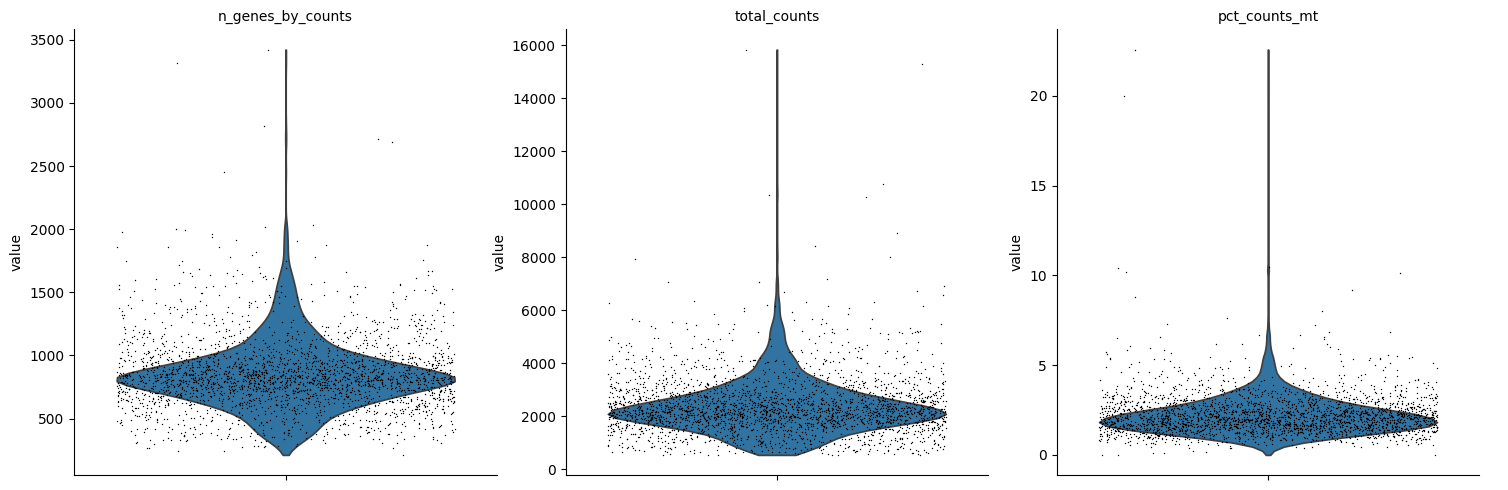

QC metrics calculated!


<Figure size 640x480 with 0 Axes>

In [2]:
%matplotlib inline
import scanpy as sc
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# Load data
adata = sc.datasets.pbmc3k()
print(f"Loaded: {adata.n_obs} cells, {adata.n_vars} genes")

# QC metrics
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# Plot QC distributions
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)
plt.savefig('figures/qc_violin.png', dpi=150, bbox_inches='tight')
print('QC metrics calculated!')

In [3]:
# Filter low quality cells
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.pct_counts_mt < 5].copy()
print(f"After QC filtering: {adata.n_obs} cells, {adata.n_vars} genes")

# Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Select top 2000 highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable].copy()
print(f"After HVG selection: {adata.n_vars} genes remaining")

After QC filtering: 2643 cells, 13714 genes
After HVG selection: 2000 genes remaining


In [4]:
# Scale, PCA, neighbors, UMAP
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

# Plot UMAP colored by cluster
sc.pl.umap(adata, color='leiden', title='PBMC clusters', save='_clusters.png')

# Save processed data
adata.write('data/processed/pbmc3k_processed.h5ad')
print('Saved!')

/home/compbio/miniconda3/envs/genomics-ml/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


ImportError: Please install the igraph package: `conda install -c conda-forge python-igraph` or `pip3 install igraph`.

In [1]:
# Scale, PCA, neighbors, UMAP
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

# Plot UMAP colored by cluster
sc.pl.umap(adata, color='leiden', title='PBMC clusters', save='_clusters.png')

# Save processed data
adata.write('data/processed/pbmc3k_processed.h5ad')
print('Saved!')

NameError: name 'sc' is not defined

In [2]:
%matplotlib inline
import scanpy as sc
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# Load data
adata = sc.datasets.pbmc3k()
print(f"Loaded: {adata.n_obs} cells, {adata.n_vars} genes")

# QC metrics
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# Filter low quality cells
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.pct_counts_mt < 5].copy()
print(f"After QC filtering: {adata.n_obs} cells, {adata.n_vars} genes")

# Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Select top 2000 highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable].copy()
print(f"After HVG selection: {adata.n_vars} genes remaining")

# Scale, PCA, neighbors, UMAP
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

# Plot UMAP
sc.pl.umap(adata, color='leiden', title='PBMC clusters', save='_clusters.png')

# Save processed data
adata.write('data/processed/pbmc3k_processed.h5ad')
print('Saved!')

Loaded: 2700 cells, 32738 genes
After QC filtering: 2643 cells, 13714 genes
After HVG selection: 2000 genes remaining


/home/compbio/miniconda3/envs/genomics-ml/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


ImportError: Please install the igraph package: `conda install -c conda-forge python-igraph` or `pip3 install igraph`.

In [1]:
%matplotlib inline
import scanpy as sc
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# Load data
adata = sc.datasets.pbmc3k()
print(f"Loaded: {adata.n_obs} cells, {adata.n_vars} genes")

# QC metrics
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

# Filter low quality cells
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.pct_counts_mt < 5].copy()
print(f"After QC filtering: {adata.n_obs} cells, {adata.n_vars} genes")

# Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Select top 2000 highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable].copy()
print(f"After HVG selection: {adata.n_vars} genes remaining")

# Scale, PCA, neighbors, UMAP
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.5)

# Plot UMAP
sc.pl.umap(adata, color='leiden', title='PBMC clusters', save='_clusters.png')

# Save processed data
adata.write('data/processed/pbmc3k_processed.h5ad')
print('Saved!')

Loaded: 2700 cells, 32738 genes
After QC filtering: 2643 cells, 13714 genes
After HVG selection: 2000 genes remaining


/home/compbio/miniconda3/envs/genomics-ml/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


ImportError: Please install the igraph package: `conda install -c conda-forge python-igraph` or `pip3 install igraph`.